Project: "India's Agricultural Evolution: Analyzing Past Growth and Forecasting Future Production"
This project will answer two main questions:
1,How has production improved? (Trends in major crops, yield increases, area changes)
2,What changes can we expect in the future? (Forecasting production for key crops)

#Step 1: Load and explore the raw data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("C:\\Users\\bhara\\Downloads\\FAOSTAT_data_en_4-9-2026 inr.csv")

In [2]:
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names and data types:")
print(df.dtypes)
print("\nSummary of 'Element' column (what we are measuring):")
print(df['Element'].value_counts())

Dataset loaded successfully!
Shape: (22936, 15)

First 5 rows:
  Domain Code                        Domain  Area Code (M49)   Area  \
0         QCL  Crops and livestock products              356  India   
1         QCL  Crops and livestock products              356  India   
2         QCL  Crops and livestock products              356  India   
3         QCL  Crops and livestock products              356  India   
4         QCL  Crops and livestock products              356  India   

   Element Code         Element Item Code (CPC)               Item  Year Code  \
0          5312  Area harvested           01371  Almonds, in shell       2010   
1          5510      Production           01371  Almonds, in shell       2010   
2          5312  Area harvested           01371  Almonds, in shell       2011   
3          5412           Yield           01371  Almonds, in shell       2011   
4          5510      Production           01371  Almonds, in shell       2011   

   Year   Unit    Value

Step 2: Clean and pivot the data
# --- Data Cleaning Function ---

In [5]:
# --- Data Cleaning Function ---
def clean_faostat_data(df_raw):
    # 1. Filter for relevant Elements
    relevant_elements = ['Area harvested', 'Yield', 'Production']
    df_filtered = df_raw[df_raw['Element'].isin(relevant_elements)].copy()
    
    # 2. Select a list of key crops for India
    # Let's get a list of all unique items to choose from
    # print(df_filtered['Item'].unique())
    
    key_crops = [
        'Wheat', 'Rice, paddy', 'Maize',           # Cereals
        'Potatoes', 'Onions, dry',                 # Vegetables
        'Mangoes, guavas and mangosteens', 'Bananas', # Fruits
        'Chick peas, dry', 'Pigeon peas, dry',     # Pulses
        'Groundnuts, excluding shelled', 'Rape or colza seed' # Oilseeds
    ]
    
    df_key_crops = df_filtered[df_filtered['Item'].isin(key_crops)].copy()
    
    # 3. Handle missing values: Convert 'Value' to numeric, coerce errors to NaN
    #    The 'Note' column indicates 'M' for missing. We'll use the 'Flag' column.
    #    Set Value to NaN if Flag is 'M'
    df_key_crops.loc[df_key_crops['Flag'] == 'M', 'Value'] = np.nan
    
    # Ensure Value is numeric
    df_key_crops['Value'] = pd.to_numeric(df_key_crops['Value'], errors='coerce')
    
    # 4. Select only necessary columns
    df_clean = df_key_crops[['Area', 'Item', 'Element', 'Year', 'Value', 'Unit']].copy()
    
    # 5. Pivot the table so Elements become columns (easier for analysis)
    df_pivot = df_clean.pivot_table(index=['Area', 'Item', 'Year'], 
                                    columns='Element', 
                                    values='Value').reset_index()
    
    # Rename columns for clarity
    df_pivot.columns.name = None
    df_pivot.rename(columns={
        'Area harvested': 'Area_Harvested_ha',
        'Yield': 'Yield_kg_per_ha',
        'Production': 'Production_t'
    }, inplace=True)
    
    # Sort by Item and Year
    df_pivot.sort_values(['Item', 'Year'], inplace=True)
    
    return df_pivot

# Apply the cleaning function
df_clean_pivot = clean_faostat_data(df)

print("Cleaned and pivoted data shape:", df_clean_pivot.shape)
print("\nFirst 10 rows of cleaned data:")
print(df_clean_pivot.head(10))
print("\nData info:")
df_clean_pivot.info()

Cleaned and pivoted data shape: (512, 6)

First 10 rows of cleaned data:
    Area     Item  Year  Area_Harvested_ha  Production_t  Yield_kg_per_ha
0  India  Bananas  1961           165000.0     2257000.0          13678.8
1  India  Bananas  1962           181000.0     2425000.0          13397.8
2  India  Bananas  1963           193000.0     2601000.0          13476.7
3  India  Bananas  1964           198000.0     2684000.0          13555.6
4  India  Bananas  1965           211000.0     3271000.0          15502.4
5  India  Bananas  1966           209000.0     3412000.0          16325.4
6  India  Bananas  1967           208000.0     3203000.0          15399.0
7  India  Bananas  1968           220000.0     3125000.0          14204.5
8  India  Bananas  1969           229800.0     3172500.0          13805.5
9  India  Bananas  1970           224500.0     2896800.0          12903.3

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 6 columns

Phase 2: Exploratory Data Analysis (EDA) - "How has production improved?"
Now we visualize the trends to tell the story of improvement.

1. Production & Yield Trends Over Time

We'll plot how production and yield for key crops have changed from 1961 to 2024.

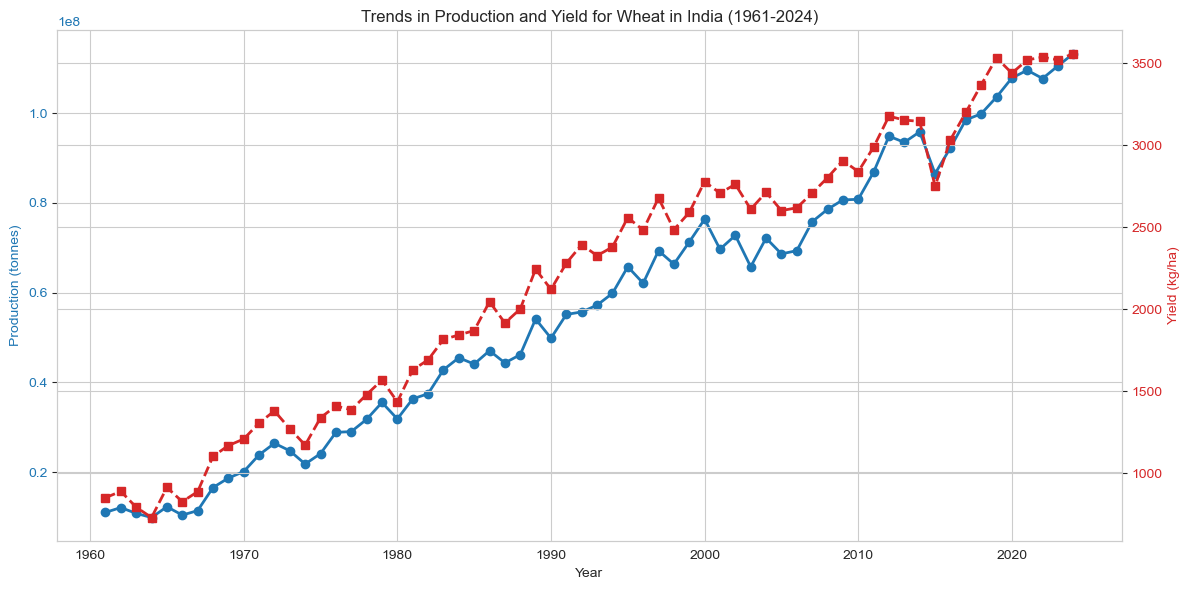

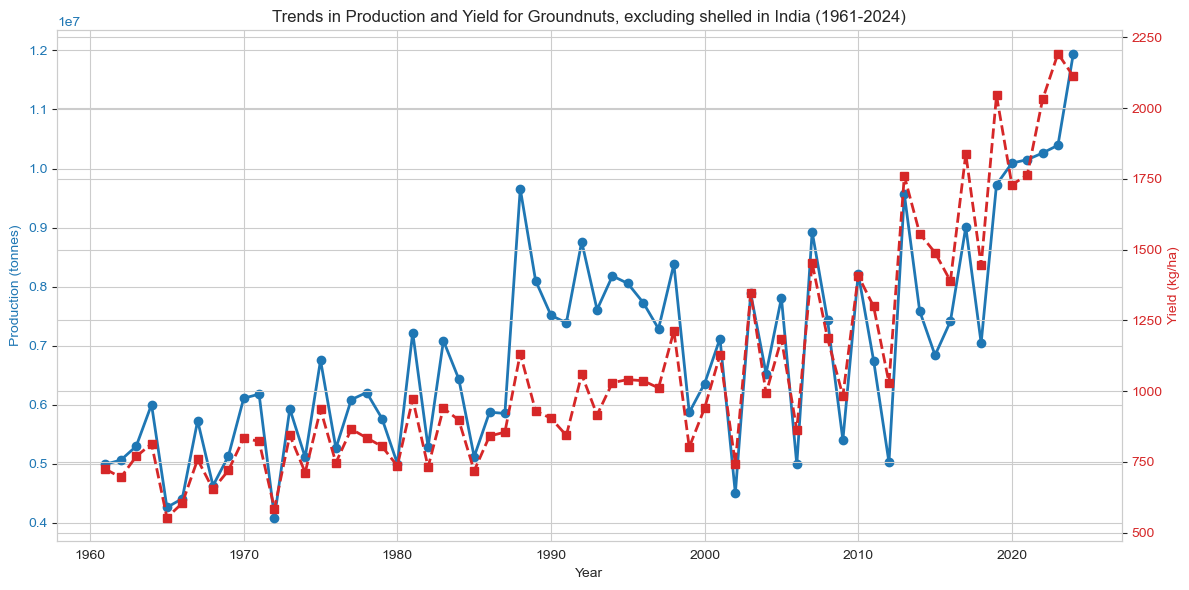

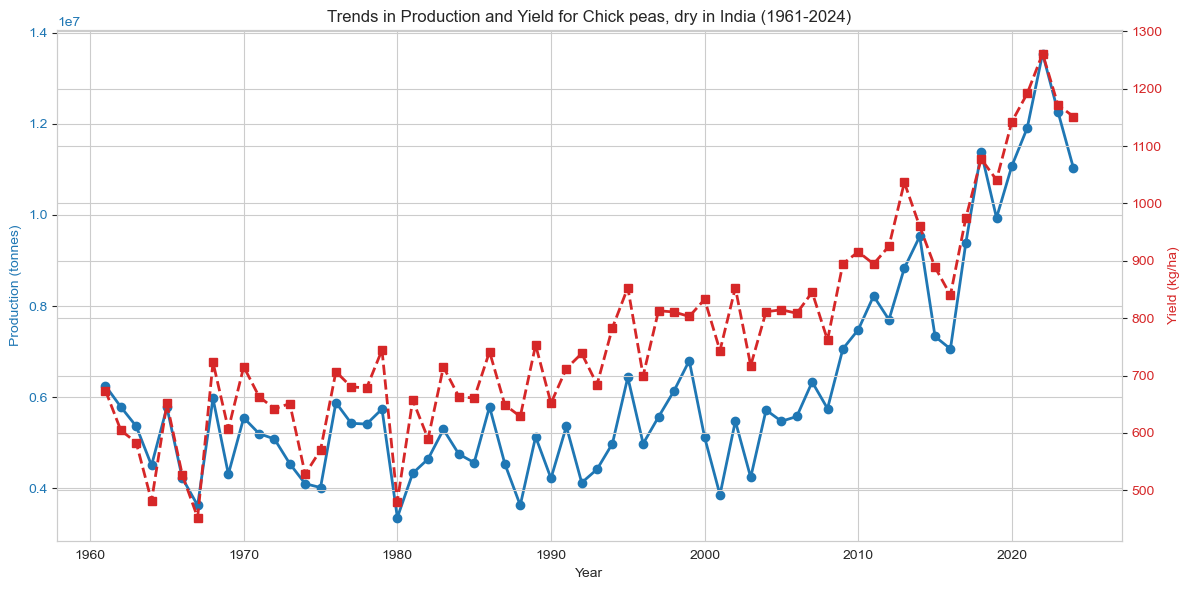

In [6]:
# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Select a few interesting crops for detailed plots
example_crops = ['Wheat', 'Maize', 'Groundnuts, excluding shelled', 'Chick peas, dry']

for crop in example_crops:
    crop_data = df_clean_pivot[df_clean_pivot['Item'] == crop].copy()
    if crop_data.empty:
        continue
        
    fig, ax1 = plt.subplots()
    
    # Plot Production on primary y-axis
    color = 'tab:blue'
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Production (tonnes)', color=color)
    ax1.plot(crop_data['Year'], crop_data['Production_t'], color=color, marker='o', linestyle='-', linewidth=2, label='Production')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create secondary y-axis for Yield
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Yield (kg/ha)', color=color)
    ax2.plot(crop_data['Year'], crop_data['Yield_kg_per_ha'], color=color, marker='s', linestyle='--', linewidth=2, label='Yield')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title(f'Trends in Production and Yield for {crop} in India (1961-2024)')
    fig.tight_layout()
    plt.show()

Interpretation for your report:
 .Wheat & Maize: You'll likely see a massive jump in production and yield starting in the late 1960s. This is the Green Revolution. Discuss the role of high-yielding varieties (HYVs), fertilizers, and irrigation.
 .Groundnuts: Production might be more volatile, tied to rainfall (monsoon dependency). Yield increases may be more gradual.
 .Chickpeas (Pulses): Production might show a different trend, possibly stagnant or slower growth compared to cereals. This highlights a policy focus on food grains over pulses.

2. Area Harvested vs. Yield - What drove the improvement?

Is production growth coming from more land or more efficiency?

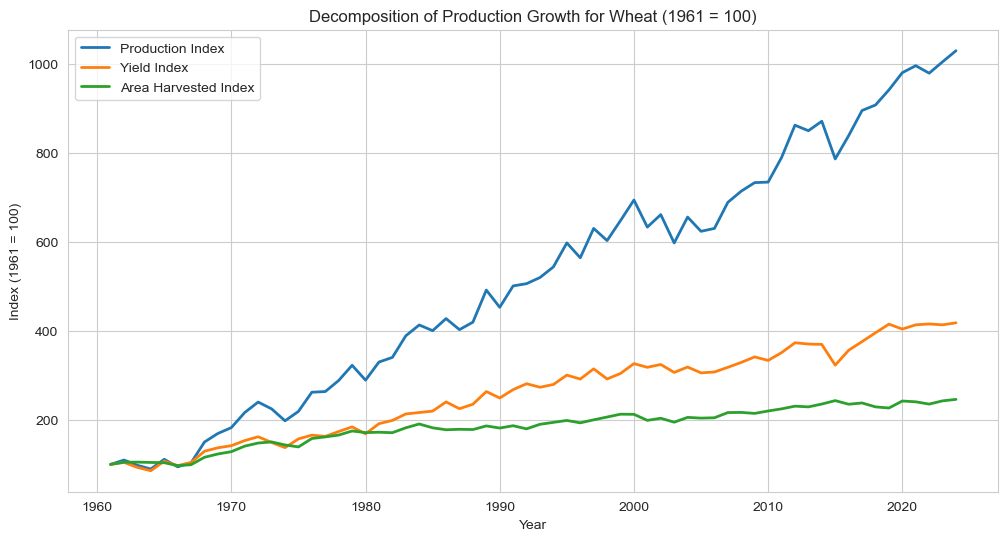

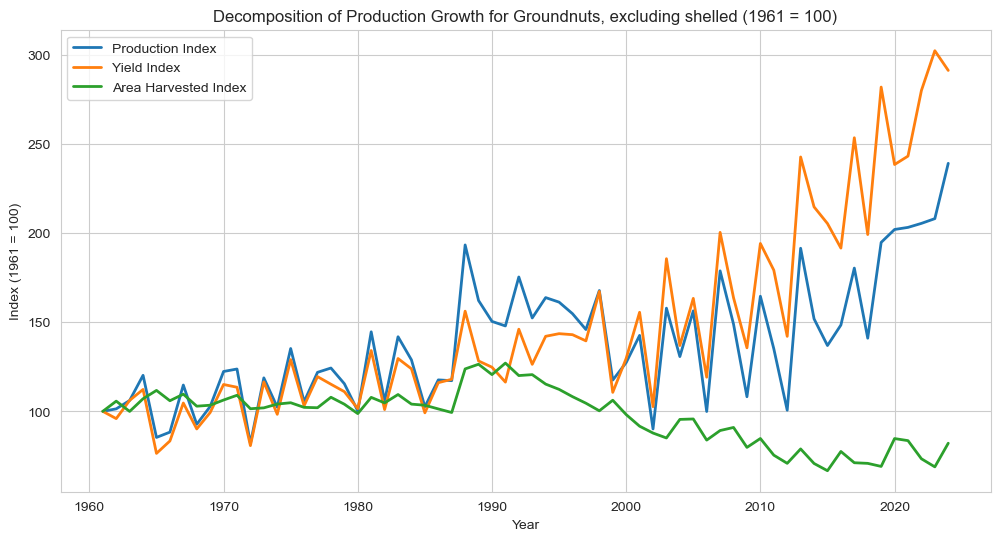

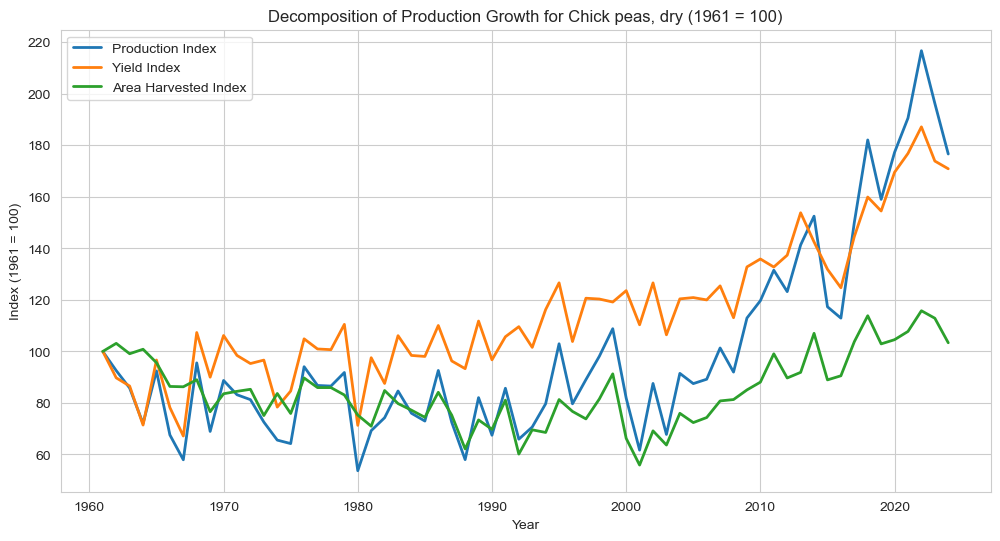

In [7]:
for crop in example_crops:
    crop_data = df_clean_pivot[df_clean_pivot['Item'] == crop].copy()
    if crop_data.empty:
        continue
    
    # Normalize data to 1961 = 100 to see relative change
    crop_data['Prod_Index'] = (crop_data['Production_t'] / crop_data['Production_t'].iloc[0]) * 100
    crop_data['Yield_Index'] = (crop_data['Yield_kg_per_ha'] / crop_data['Yield_kg_per_ha'].iloc[0]) * 100
    crop_data['Area_Index'] = (crop_data['Area_Harvested_ha'] / crop_data['Area_Harvested_ha'].iloc[0]) * 100
    
    plt.figure()
    plt.plot(crop_data['Year'], crop_data['Prod_Index'], label='Production Index', linewidth=2)
    plt.plot(crop_data['Year'], crop_data['Yield_Index'], label='Yield Index', linewidth=2)
    plt.plot(crop_data['Year'], crop_data['Area_Index'], label='Area Harvested Index', linewidth=2)
    plt.title(f'Decomposition of Production Growth for {crop} (1961 = 100)')
    plt.xlabel('Year')
    plt.ylabel('Index (1961 = 100)')
    plt.legend()
    plt.show()

Interpretation:
.For Cereals (Wheat/Maize): You'll see the Yield Index skyrocket, far outpacing the Area Index. This proves that the Green Revolution's success was primarily due to increased efficiency (yield) , not just planting more land.
.For other crops: The story might be different. Some may show growth driven by both area and yield, others might be stagnant.

3. Shift in Crop Composition
Has India moved from growing low-value to high-value crops?

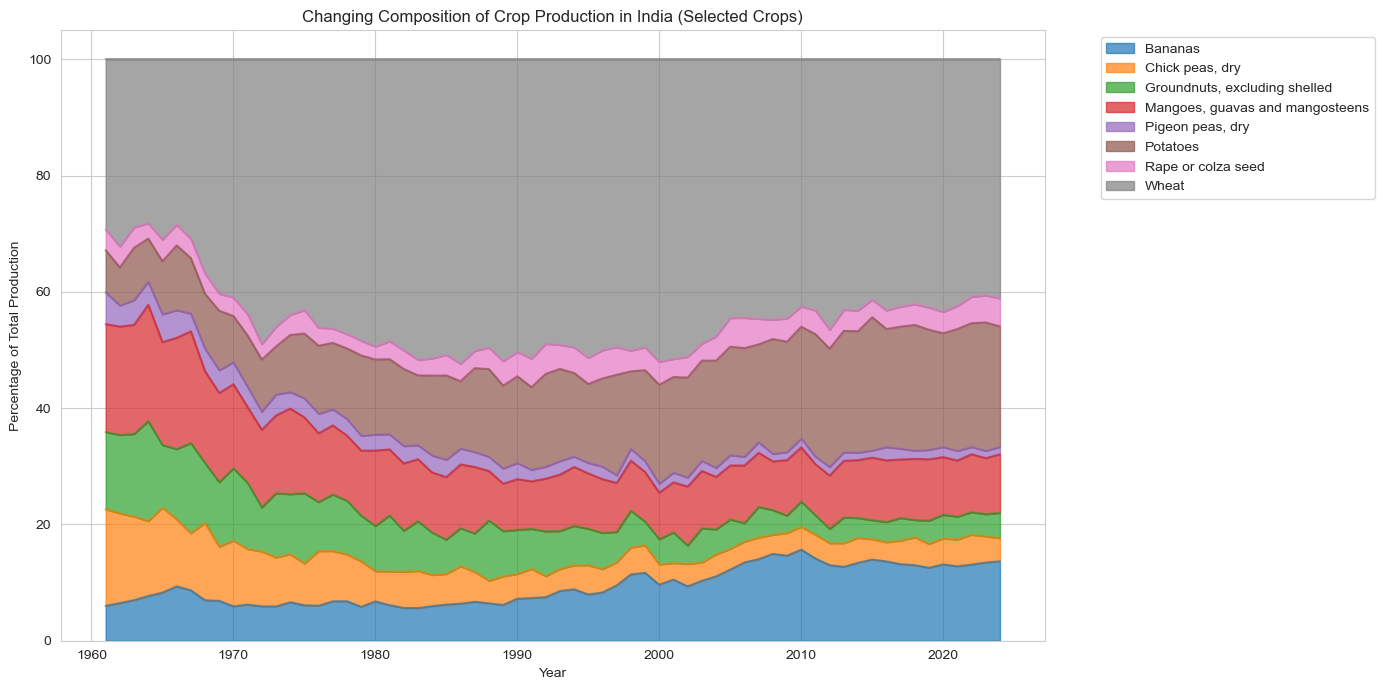

In [8]:
# Calculate the proportion of production for key crops over time
# First, filter for just 'Production' data for our key crops
prod_data = df_clean_pivot[['Year', 'Item', 'Production_t']].dropna()

# For each year, calculate the total production of our selected crops
# (We are only looking at our key_crops, not all of Indian ag)
yearly_total = prod_data.groupby('Year')['Production_t'].sum().reset_index()
yearly_total.rename(columns={'Production_t': 'Total_Production'}, inplace=True)

# Merge and calculate percentage
prod_data = prod_data.merge(yearly_total, on='Year')
prod_data['Percentage'] = (prod_data['Production_t'] / prod_data['Total_Production']) * 100

# Pivot for plotting
pivot_perc = prod_data.pivot(index='Year', columns='Item', values='Percentage')

# Plot area chart
pivot_perc.plot.area(figsize=(14, 7), alpha=0.7)
plt.title('Changing Composition of Crop Production in India (Selected Crops)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Production')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Interpretation:
 .Look for the dominance of rice and wheat post-1970s.
 .Notice if the share of fruits (mangoes, bananas) and vegetables (potatoes, onions) increases in recent decades. This indicates diversification towards higher-value horticulture, a major trend in modern Indian agriculture.

Phase 3: Predictive Modeling - "What changes will it make in the future?"
A simple but effective time series forecast for the production of one major crop, like Wheat.
use the Holt-Winters Exponential Smoothing model, which is great for data with trends and seasonality.(Note: Our yearly data has a strong trend, we'll use a trend component).

Data for Wheat:
      Production_t
Year              
1961    10997000.0
1962    12072000.0
1963    10776000.0
1964     9853000.0
1965    12257000.0

Training years: 1961 to 2014
Testing years: 2015 to 2024

Model Performance on Test Set (2015-2024):
Mean Absolute Error (MAE): 2,953,253 tonnes
Root Mean Squared Error (RMSE): 4,306,773 tonnes


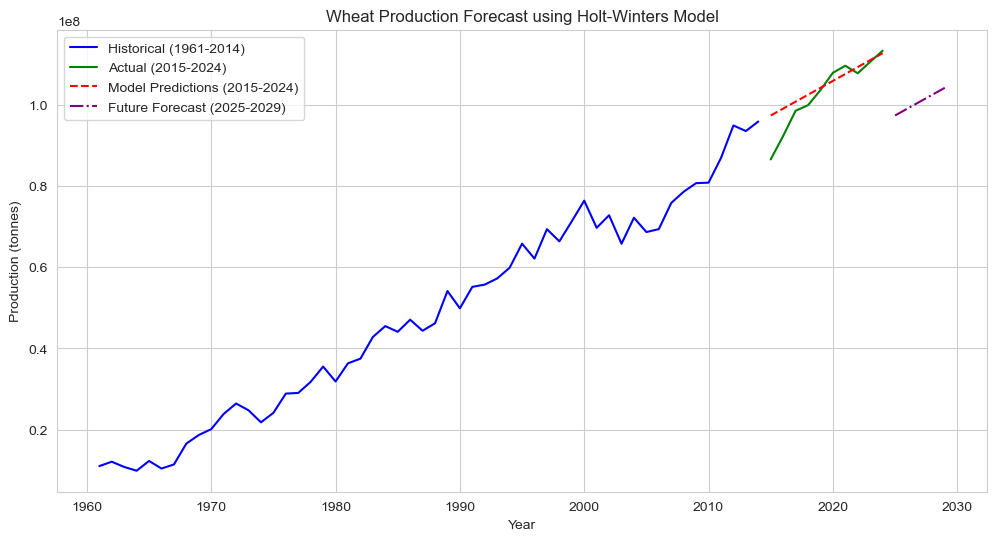


Forecast for 2025-2029:
2025    9.734104e+07
2026    9.904518e+07
2027    1.007493e+08
2028    1.024535e+08
2029    1.041576e+08
dtype: float64


In [9]:
# Select data for a single crop, e.g., 'Wheat'
crop_name = 'Wheat'  # You can change this to 'Rice, paddy' or 'Maize'
crop_forecast_data = df_clean_pivot[df_clean_pivot['Item'] == crop_name][['Year', 'Production_t']].dropna().copy()
crop_forecast_data.set_index('Year', inplace=True)

print(f"Data for {crop_name}:")
print(crop_forecast_data.head())

# Split data into training and testing sets
# Use data from 1961 to 2014 for training, 2015-2024 for testing
train = crop_forecast_data[crop_forecast_data.index <= 2014]
test = crop_forecast_data[crop_forecast_data.index >= 2015]

print(f"\nTraining years: {train.index.min()} to {train.index.max()}")
print(f"Testing years: {test.index.min()} to {test.index.max()}")

# Fit the Holt-Winters model (additive trend, as production is increasing)
# We'll use ExponentialSmoothing from statsmodels
model = ExponentialSmoothing(train['Production_t'], 
                            trend='additive', 
                            seasonal=None,  # No seasonality as we have yearly data
                            initialization_method='estimated')
fitted_model = model.fit()

# Make predictions for the test period
predictions = fitted_model.forecast(steps=len(test))

# Evaluate the model
mae = mean_absolute_error(test['Production_t'], predictions)
rmse = mean_squared_error(test['Production_t'], predictions, squared=False)
print(f"\nModel Performance on Test Set (2015-2024):")
print(f"Mean Absolute Error (MAE): {mae:,.0f} tonnes")
print(f"Root Mean Squared Error (RMSE): {rmse:,.0f} tonnes")

# Forecast for the next 5 years (2025-2029)
future_years = [2025, 2026, 2027, 2028, 2029]
future_forecast = fitted_model.forecast(steps=5)
future_forecast.index = future_years

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Production_t'], label='Historical (1961-2014)', color='blue')
plt.plot(test.index, test['Production_t'], label='Actual (2015-2024)', color='green')
plt.plot(test.index, predictions, label='Model Predictions (2015-2024)', color='red', linestyle='--')
plt.plot(future_forecast.index, future_forecast, label='Future Forecast (2025-2029)', color='purple', linestyle='-.')
plt.title(f'{crop_name} Production Forecast using Holt-Winters Model')
plt.xlabel('Year')
plt.ylabel('Production (tonnes)')
plt.legend()
plt.grid(True)
plt.show()

print("\nForecast for 2025-2029:")
print(future_forecast)

What this tells:
.The model tries to learn the historical trend and project it forward.
.The forecast suggests that if past trends (technology, policy, area expansion) continue, wheat production will keep increasing.

#Critical Discussion Point: A simple extrapolation ignores constraints. Future changes might be limited by:
   .Stagnating Yields: The rapid gains of the Green Revolution may be over.
   .Climate Change: Increasing temperatures, erratic rainfall, and more frequent droughts/floods will impact yields, especially for water-intensive crops like wheat and rice.
   .Groundwater Depletion: Intensive farming has drained aquifers in Punjab and Haryana, the "breadbasket" of India.
   .Soil Degradation: Overuse of fertilizers has led to soil health issues.
   .Policy Shifts: Government policies (MSP, subsidies) and international trade agreements.
   .

Phase 4: Conclusion & Future Changes Report
  #Data-Driven Analysis of India's Agricultural Transformation: Past Improvements and Future Trajectories

3. Future Outlook & Predicted Changes (2025-2029 & Beyond):

Quantitative Forecast: Present your Holt-Winters forecast for a major crop (e.g., wheat). State the predicted production for 2029.

Limitations of the Forecast: Acknowledge that this is a trend-based projection. It does not account for disruptive changes.

Qualitative Predictions (The "What Changes"): Based on current challenges, predict the following changes:

Shift to Climate-Resilient Crops: Expect policy and farmer incentives to move away from water-guzzling rice/wheat towards millets, pulses, and oilseeds.

Precision Agriculture & Technology: Adoption of AI, IoT, drones, and data-driven farming to optimize inputs (water, fertilizer) and combat climate variability.

Supply Chain Modernization: Growth of cold storage, efficient logistics, and direct-to-consumer platforms (e.g., Otipy, Ninjacart) to reduce post-harvest losses.

Sustainability Focus: A rise in organic farming, natural farming, and carbon credit programs for agriculture.

4. Recommendations:

For Policymakers: Invest in R&D for drought-resistant varieties, reform water policies, and strengthen agricultural extension services for modern techniques.

For Farmers: Diversify cropping patterns, adopt data-driven farming, and explore direct marketing channels.

For Agribusiness: Focus on post-harvest management, processing, and climate-resilient supply chains.

Phase 5: Providing the Final Cleaned Dataset

In [10]:
# Save the cleaned and pivoted dataset
output_filename = 'india_agriculture_cleaned_data.csv'
df_clean_pivot.to_csv(output_filename, index=False)
print(f"Cleaned dataset saved as '{output_filename}'")

Cleaned dataset saved as 'india_agriculture_cleaned_data.csv'
